In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(2,-2,50)
Y = 3*x+2*x**2

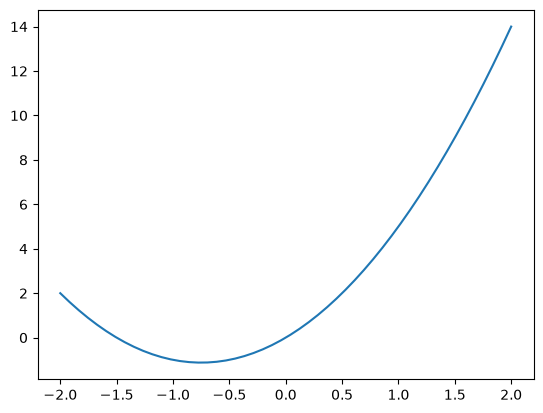

In [3]:
plt.plot(x,Y)

In [4]:
Theta = np.column_stack([np.ones_like(x), x, x**2, x**3, x**4])
print(Theta.shape)
print(Theta[:5])
coeff = np.linalg.lstsq(Theta, Y, rcond=None)[0]
print(coeff)


(50, 5)
[[ 1.          2.          4.          8.         16.        ]
 [ 1.          1.91836735  3.68013328  7.05984751 13.54338094]
 [ 1.          1.83673469  3.37359434  6.19639776 11.38113874]
 [ 1.          1.75510204  3.08038317  5.40638679  9.4887605 ]
 [ 1.          1.67346939  2.80049979  4.68655067  7.84279908]]
[ 4.30644573e-16  3.00000000e+00  2.00000000e+00  1.52049967e-15
 -1.33226763e-15]


Text(0.5, 1.0, 'Polynomial Regression Fit')

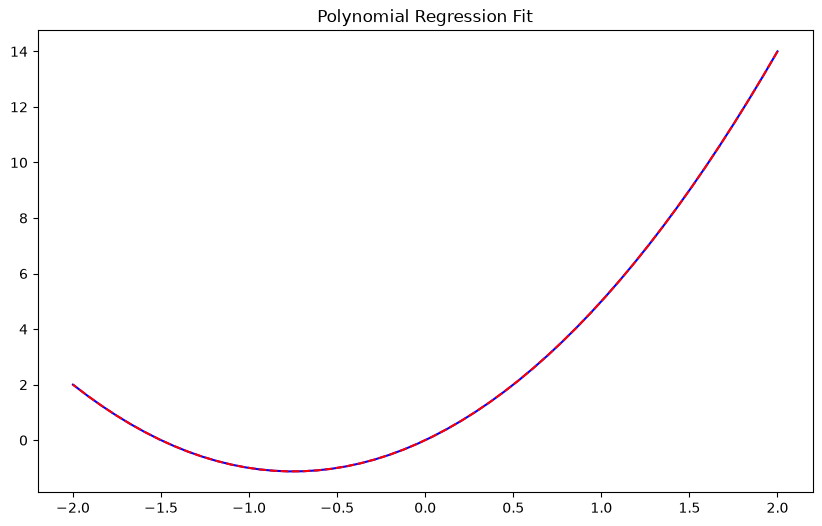

In [5]:
y_pred = Theta @ coeff

plt.figure(figsize=(10,6))
plt.plot(x,Y, label='True function', color='blue')  
plt.plot(x,y_pred, label='Fitted polynomial', color='red', linestyle='--')
plt.title('Polynomial Regression Fit')  


In [6]:
terms = ['1', 'x', 'x^2', 'x^3', 'x^4']
print("recoverdequations:\n")
for i, c in enumerate(coeff):
    print(f"{c:.4f} * {terms[i]}")

recoverdequations:

0.0000 * 1
3.0000 * x
2.0000 * x^2
0.0000 * x^3
-0.0000 * x^4


In [7]:
# Reproducibility
np.random.seed(42)

# Input data
x = np.linspace(-2, 2, 50)

# True equation
y_true = 3*x + 2*x**2

noise = 0.5 * np.random.randn(len(x))
y = y_true + noise

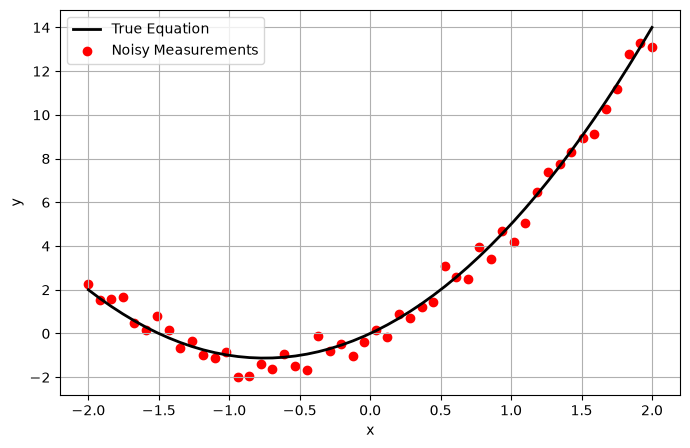

In [8]:
plt.figure(figsize=(8,5))

plt.plot(x, y_true, 'k', linewidth=2, label='True Equation')

plt.scatter(x, y,
            color='red',
            label='Noisy Measurements')

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
Theta = np.column_stack([
    np.ones_like(x),
    x,
    x**2,
    x**3,
    x**4,
    x**5,
    x**6,
    x**7,
    x**8,
    x**9,
    x**10
])

In [10]:
coeff = np.linalg.lstsq(Theta, y, rcond=None)[0]
terms = [
    "1",
    "x",
    "x²",
    "x³",
    "x⁴",
    "x⁵",
    "x⁶",
    "x⁷",
    "x⁸",
    "x⁹",
    "x¹⁰"
]

print("Recovered coefficients\n")

for t,c in zip(terms,coeff):
    print(f"{t:>4} : {c:12.6f}")

Recovered coefficients

   1 :    -0.080710
   x :     2.971073
  x² :     1.248341
  x³ :     1.037484
  x⁴ :     1.012543
  x⁵ :    -1.328942
  x⁶ :    -0.549324
  x⁷ :     0.509597
  x⁸ :     0.150093
  x⁹ :    -0.061304
 x¹⁰ :    -0.016247


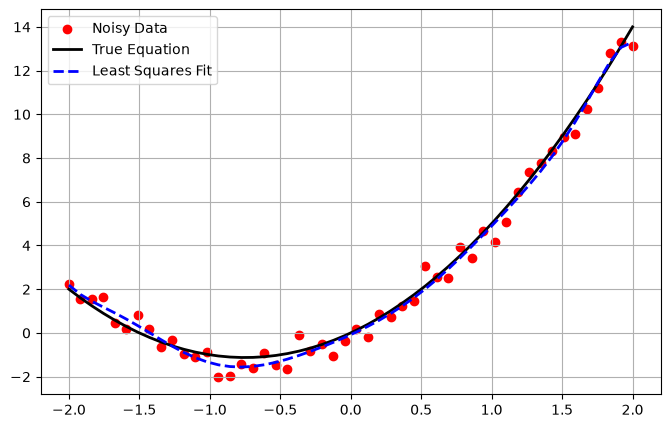

In [11]:
y_pred = Theta @ coeff

plt.figure(figsize=(8,5))

plt.scatter(x, y,
            color='red',
            label='Noisy Data')

plt.plot(x, y_true,
         'k',
         linewidth=2,
         label='True Equation')

plt.plot(x, y_pred,
         '--b',
         linewidth=2,
         label='Least Squares Fit')

plt.legend()
plt.grid(True)
plt.show()

### Conclusion

Noise causes ordinary least squares to assign small nonzero coefficients to unnecessary polynomial terms. While the model fits the data well, it is not sparse or easily interpretable. This motivates the use of sparse regression methods such as **STLSQ** to identify the true governing equation by eliminating insignificant terms.
